In [ ]:
!pip install colormath

In [ ]:
import numpy as np
np.asscalar = lambda a: a.item()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from skimage.color import rgb2lab, deltaE_ciede2000


IMAGE_FOLDER = '/content/drive/MyDrive/images'


images = [f for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print("Available images:", images)

Available images: ['dark.jpg', 'saturated.jpg', 'normal.jpg']


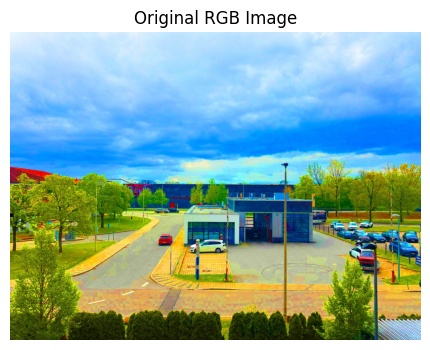

Image shape: (1200, 1600, 3)


In [ ]:

image_path = os.path.join(IMAGE_FOLDER, images[1])

img_pil = Image.open(image_path).convert('RGB')
img_rgb = np.array(img_pil, dtype=np.float32) / 255.0

plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis('off')
plt.show()

print("Image shape:", img_rgb.shape)

In [ ]:

#rgb to cmyk usinig the formula

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]


K = 1.0 - np.maximum(np.maximum(R, G), B)


denom = 1.0 - K

C = np.where(denom == 0, 0.0, (1.0 - R - K) / denom)
M = np.where(denom == 0, 0.0, (1.0 - G - K) / denom)
Y = np.where(denom == 0, 0.0, (1.0 - B - K) / denom)


C = np.clip(C, 0.0, 1.0)
M = np.clip(M, 0.0, 1.0)
Y = np.clip(Y, 0.0, 1.0)
K = np.clip(K, 0.0, 1.0)

print("CMYK channels computed successfully!")
print("Shapes — C:", C.shape, "M:", M.shape, "Y:", Y.shape, "K:", K.shape)

CMYK channels computed successfully!
Shapes — C: (1200, 1600) M: (1200, 1600) Y: (1200, 1600) K: (1200, 1600)


/tmp/ipykernel_5924/3806434057.py:13: RuntimeWarning: invalid value encountered in divide
  C = np.where(denom == 0, 0.0, (1.0 - R - K) / denom)
/tmp/ipykernel_5924/3806434057.py:14: RuntimeWarning: invalid value encountered in divide
  M = np.where(denom == 0, 0.0, (1.0 - G - K) / denom)
/tmp/ipykernel_5924/3806434057.py:15: RuntimeWarning: invalid value encountered in divide
  Y = np.where(denom == 0, 0.0, (1.0 - B - K) / denom)


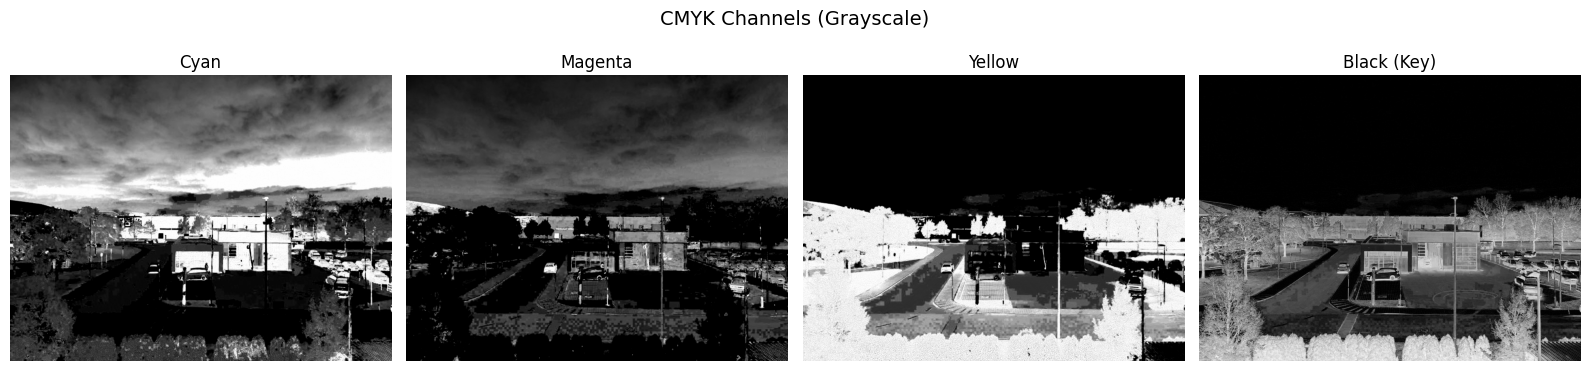

In [ ]:
channel_names = ['Cyan', 'Magenta', 'Yellow', 'Black (Key)']
channels = [C, M, Y, K]
save_folder = '/content/'

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (ch, name) in enumerate(zip(channels, channel_names)):
    axes[i].imshow(ch, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')

plt.suptitle("CMYK Channels (Grayscale)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#saving cmyk channels as grayscales
for ch, name in zip(channels, channel_names):
    ch_uint8 = (ch * 255).astype(np.uint8)
    ch_img = Image.fromarray(ch_uint8, mode='L')
    filename = os.path.join(save_folder, f'channel_{name.split()[0]}.png')
    ch_img.save(filename)
    print(f"Saved: {filename}")

/tmp/ipykernel_5924/3963718221.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  ch_img = Image.fromarray(ch_uint8, mode='L')


Saved: /content/channel_Cyan.png
Saved: /content/channel_Magenta.png
Saved: /content/channel_Yellow.png
Saved: /content/channel_Black.png


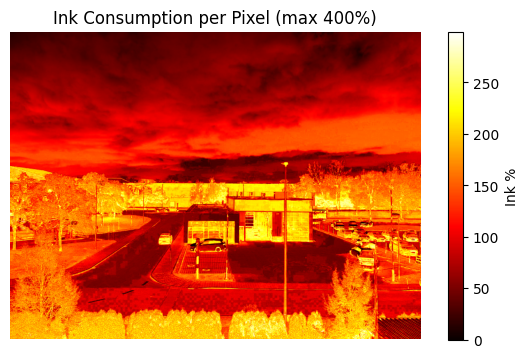

Average ink consumption: 109.4%
Max ink consumption:     299.6%
Min ink consumption:     0.0%


In [ ]:
# total in per ppixel
ink_consumption = (C + M + Y + K) * 100

plt.figure(figsize=(7, 4))
plt.imshow(ink_consumption, cmap='hot')
plt.colorbar(label='Ink %')
plt.title("Ink Consumption per Pixel (max 400%)")
plt.axis('off')
plt.show()

print(f"Average ink consumption: {ink_consumption.mean():.1f}%")
print(f"Max ink consumption:     {ink_consumption.max():.1f}%")
print(f"Min ink consumption:     {ink_consumption.min():.1f}%")

In [ ]:
def apply_ink_limit(C, M, Y, K, limit_percent):
    """
    Apply total ink limit while preserving black channel.

    """

    limit = limit_percent / 100.0
    total = C + M + Y + K

    # Copies
    C_new = C.copy()
    M_new = M.copy()
    Y_new = Y.copy()
    K_new = K.copy()

    # Pixels exceeding the total ink limit
    mask = total > limit

    # Keep K fixed, reduce only CMY
    available_cmy = np.maximum(limit - K[mask], 0.0)
    current_cmy = C[mask] + M[mask] + Y[mask]

    ratio = np.ones_like(current_cmy)
    nz = current_cmy > 1e-8
    ratio[nz] = available_cmy[nz] / current_cmy[nz]
    ratio = np.clip(ratio, 0, 1)

    C_new[mask] = C[mask] * ratio
    M_new[mask] = M[mask] * ratio
    Y_new[mask] = Y[mask] * ratio

    return C_new, M_new, Y_new, K_new

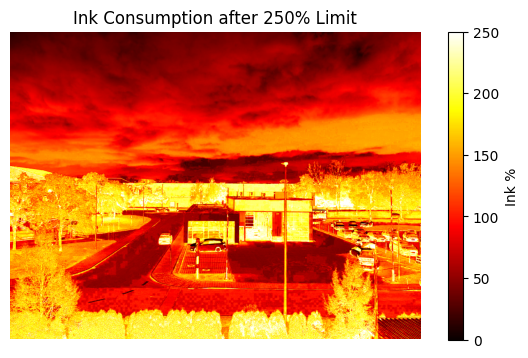

[250% limit] Max: 250.0%  |  Avg: 109.3%


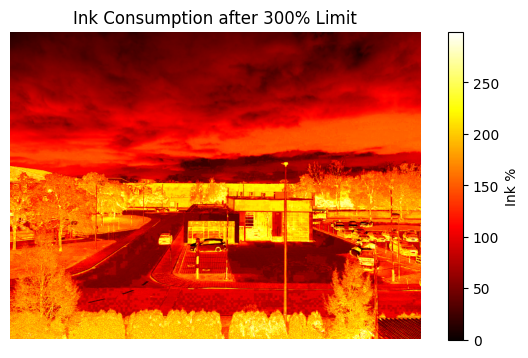

[300% limit] Max: 299.6%  |  Avg: 109.4%


In [ ]:
#apply and visualize both limits
for limit in [250, 300]:
    C_l, M_l, Y_l, K_l = apply_ink_limit(C, M, Y, K, limit)
    ink_limited = (C_l + M_l + Y_l + K_l) * 100

    plt.figure(figsize=(7, 4))
    plt.imshow(ink_limited, cmap='hot')
    plt.colorbar(label='Ink %')
    plt.title(f"Ink Consumption after {limit}% Limit")
    plt.axis('off')
    plt.show()

    print(f"[{limit}% limit] Max: {ink_limited.max():.1f}%  |  Avg: {ink_limited.mean():.1f}%")

In [ ]:
from skimage.color import rgb2lab, deltaE_ciede2000
import numpy as np

def compute_delta_e_map(img_orig, img_recon):
    """
    Computes full-resolution Delta-E 2000 perceptual color difference map.
    Both images must be RGB float arrays in range [0,1].
    Returns a 2D Delta-E map.
    """


    img_orig = np.clip(img_orig.astype(np.float32), 0, 1)
    img_recon = np.clip(img_recon.astype(np.float32), 0, 1)

    # this will convert the images into LAB space
    lab_orig = rgb2lab(img_orig)
    lab_recon = rgb2lab(img_recon)

    # calculating the deltaE at pixel
    delta_map = deltaE_ciede2000(lab_orig, lab_recon)

    return delta_map

In [ ]:
def cmyk_to_rgb(C, M, Y, K):
    R = (1 - C) * (1 - K)
    G = (1 - M) * (1 - K)
    B = (1 - Y) * (1 - K)
    return np.stack([R, G, B], axis=-1)

rgb_reconstructed_250 = cmyk_to_rgb(*apply_ink_limit(C, M, Y, K, 250))
rgb_reconstructed_300 = cmyk_to_rgb(*apply_ink_limit(C, M, Y, K, 300))

In [ ]:
print("Computing Delta-E map for 250% limit...")
delta_map_250 = compute_delta_e_map(img_rgb, rgb_reconstructed_250)

print("Computing Delta-E map for 300% limit...")
delta_map_300 = compute_delta_e_map(img_rgb, rgb_reconstructed_300)

print("Done!")

Computing Delta-E map for 250% limit...
Computing Delta-E map for 300% limit...
Done!


[250%] Avg ΔE: 0.0045 | Max ΔE: 2.12 | P95 ΔE: 0.0000
[300%] Avg ΔE: 0.0000 | Max ΔE: 0.00 | P95 ΔE: 0.0000


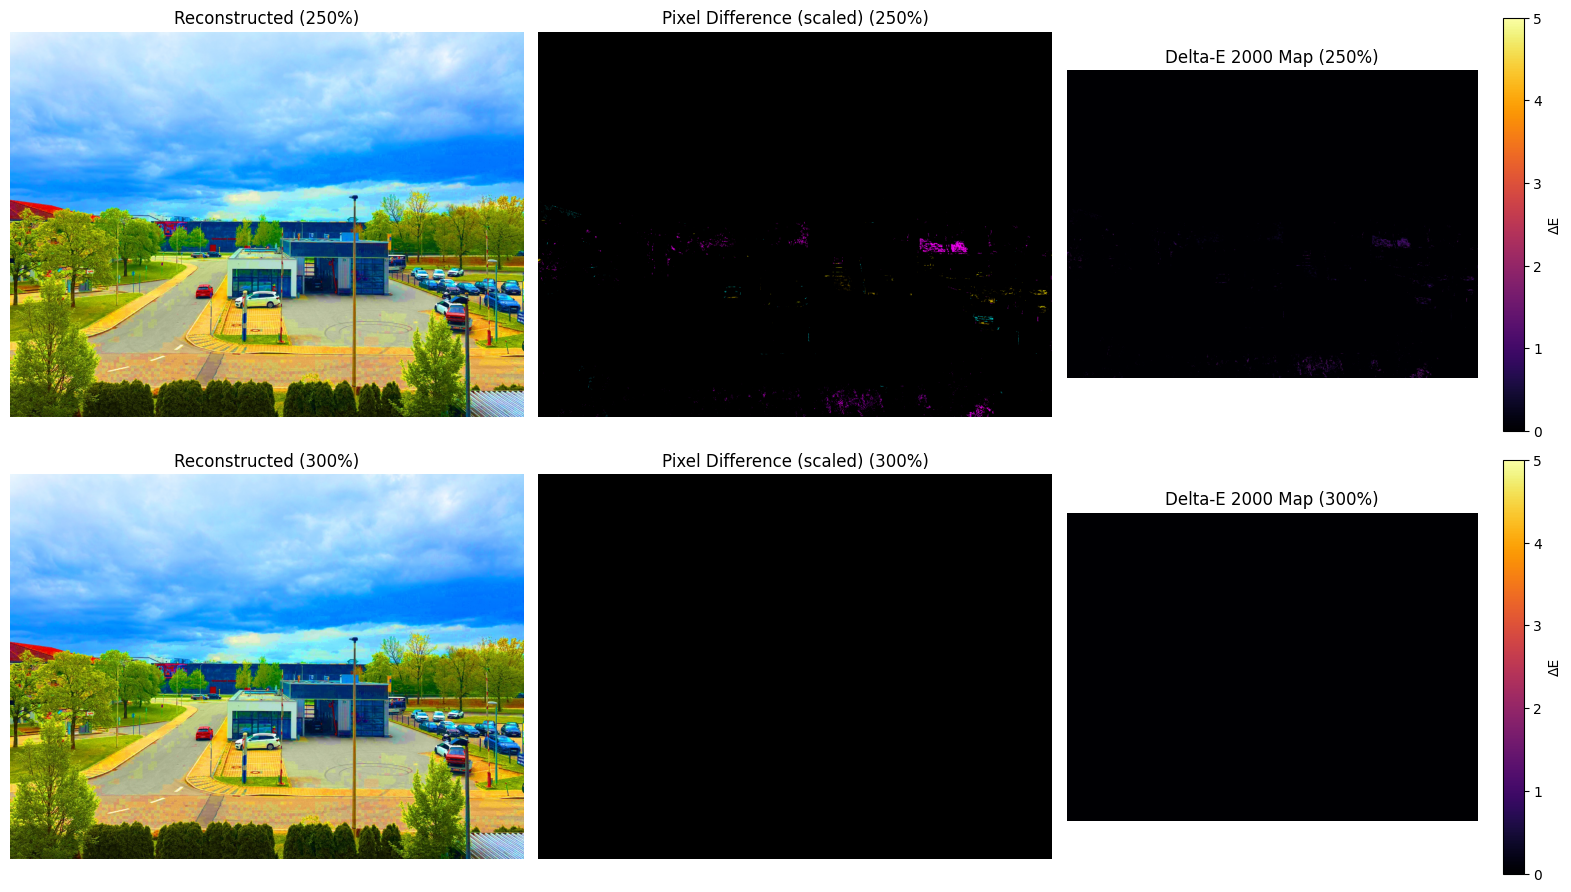

In [ ]:
# to visualize raw and reconstructed image after processing the whole pipeline
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (recon, dmap, label) in enumerate([
    (rgb_reconstructed_250, delta_map_250, "250%"),
    (rgb_reconstructed_300, delta_map_300, "300%"),
]):

    diff = np.abs(img_rgb - recon)

    # Use FIXED scaling (not per-image normalization)
    diff_scaled = np.clip(diff * 50, 0, 1)  # 20–100 if needed

    # reconstructing the image
    axes[row, 0].imshow(np.clip(recon, 0, 1))
    axes[row, 0].set_title(f"Reconstructed ({label})")
    axes[row, 0].axis('off')

    # this will show the pixel difference
    axes[row, 1].imshow(diff_scaled)
    axes[row, 1].set_title(f"Pixel Difference (scaled) ({label})")
    axes[row, 1].axis('off')

    # delta e map
    im = axes[row, 2].imshow(dmap, cmap='inferno', vmin=0, vmax=5)
    axes[row, 2].set_title(f"Delta-E 2000 Map ({label})")
    axes[row, 2].axis('off')

    plt.colorbar(im, ax=axes[row, 2], label='ΔE')


    print(
        f"[{label}] "
        f"Avg ΔE: {dmap.mean():.4f} | "
        f"Max ΔE: {dmap.max():.2f} | "
        f"P95 ΔE: {np.percentile(dmap, 95):.4f}"
    )

plt.tight_layout()
plt.show()

'import numpy as np\n\ndef apply_ink_limit(C, M, Y, K, limit_percent):\n    """\n    Apply total ink limit while preserving black channel as much as possible.\n    limit_percent: e.g. 250 or 300\n    CMYK inputs are float arrays in [0,1]\n    """\n\n    limit = limit_percent / 100.0   # 250% -> 2.5\n\n    total = C + M + Y + K\n\n    # Start with copies\n    C_new = C.copy()\n    M_new = M.copy()\n    Y_new = Y.copy()\n    K_new = K.copy()\n\n    # Pixels exceeding ink limit\n    mask = total > limit\n\n    # Available ink for CMY after keeping K\n    available_cmy = np.maximum(limit - K[mask], 0.0)\n\n    current_cmy = C[mask] + M[mask] + Y[mask]\n\n    # Avoid division by zero\n    ratio = np.ones_like(current_cmy)\n    nonzero = current_cmy > 1e-8\n    ratio[nonzero] = available_cmy[nonzero] / current_cmy[nonzero]\n\n    # Clamp ratio\n    ratio = np.clip(ratio, 0, 1)\n\n    # Reduce only CMY\n    C_new[mask] = C[mask] * ratio\n    M_new[mask] = M[mask] * ratio\n    Y_new[mask] = Y[